In [1]:
import os
import json
import textwrap
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def list_subdirectories(flux_dir):
    return [
        name for name in os.listdir(flux_dir)
        if os.path.isdir(os.path.join(flux_dir, name)) and 'logs' not in name
    ]


In [2]:

filtered_flux_results_path = '/home/jhpark/image-artifacts/src/new_filtering'
filtered_flux_results_dirs = list_subdirectories(filtered_flux_results_path)

In [3]:
def plot_explanations(parent_dir, subdirectory):
    metadata_path = os.path.join(parent_dir, subdirectory, "metadata.json")
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    artifact_image_path = os.path.join(parent_dir, subdirectory, "artifact_image.png")
    img = mpimg.imread(artifact_image_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')

    for idx, artifact in enumerate(metadata):
        bbox = artifact['target_bbox']
        x1, y1, x2, y2 = bbox
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
        plt.gca().add_patch(rect)
        plt.gca().text(x1, y1 - 5, str(idx) +' ' + artifact['artifact_type'], color='white', fontsize=12, weight='bold', va='bottom', ha='left', bbox=dict(facecolor='r', alpha=0.5, edgecolor='none', pad=1))
        print('\n'.join(textwrap.wrap(artifact['explanation'], width=80)))
        print('--------------------------------')
    plt.show()
        


In [4]:
flux_results_iter = iter(filtered_flux_results_dirs)

The heads of the cows are merged, creating an unnatural blend of features.
--------------------------------
The cow's horn is missing, leaving an unnatural gap where the horn should be.
The area appears smoothed over, disrupting the symmetry of the cow's head.
--------------------------------


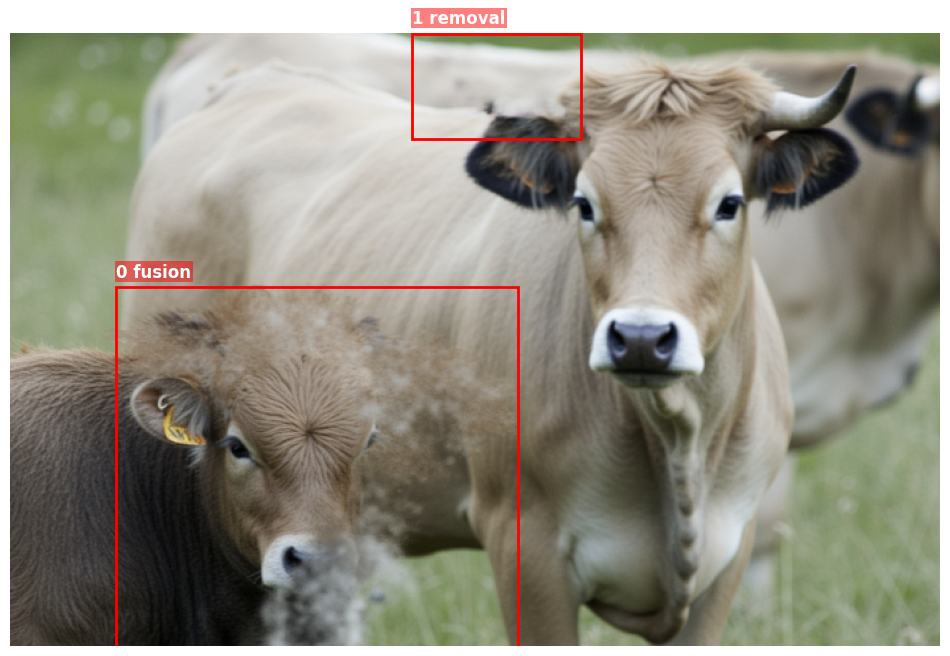

In [19]:
flux_result = next(flux_results_iter)
plot_explanations(filtered_flux_results_path, flux_result)